# **The Case for Jamaica**: A Caribbean Investment Analysis
# **Target Audience**:
# This analysis is designed for **prospective institutional investors** evaluating opportunities in the Caribbean region.
# Caribbean economies have generally trended upward over the past two decades, but with significant variation across countries. This raises a key question: **which Caribbean economy offers the best risk-adjusted outlook for investment?**

# This report makes the case for Jamaica by:
1. Comparing macroeconomic fundamentals across nine Caribbean nations
2. Examining Jamaica's fiscal transformation, particularly its dramatic debt-to-GDP reduction
3. Modeling the drivers of GDP growth and contraction risk across the region

In [68]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np

## Data Collection
We pull five macroeconomic indicators from the World Bank API for nine Caribbean nations: Jamaica, Trinidad & Tobago, Barbados, The Bahamas, Dominican Republic, Haiti, Guyana, Belize, and Grenada.

In [71]:
countries = "JAM;TTO;BRB;BHS;DOM;HTI;GUY;BLZ;GRD"
url = f"https://api.worldbank.org/v2/country/{countries}/indicator/NY.GDP.PCAP.CD"
params = {"format": "json", "per_page": 1000}
response = requests.get(url, params=params)

caribbean_gdp = pd.DataFrame(response.json()[1])

In [72]:
caribbean_gdp = caribbean_gdp[['country', 'date', 'value']]
caribbean_gdp['country'] = caribbean_gdp['country'].apply(lambda x: x['value'])
caribbean_gdp.columns = ['country', 'year', 'gdp_per_capita']
caribbean_gdp['year'] = caribbean_gdp['year'].astype(int)
caribbean_gdp['country'].unique()

<ArrowStringArray>
[       'Bahamas, The',              'Belize',            'Barbados',
  'Dominican Republic',             'Grenada',              'Guyana',
               'Haiti',             'Jamaica', 'Trinidad and Tobago']
Length: 9, dtype: str

In [73]:
# FDI net inflows (% of GDP)
fdi_url = f"https://api.worldbank.org/v2/country/{countries}/indicator/BX.KLT.DINV.WD.GD.ZS"
fdi_response = requests.get(fdi_url, params={"format": "json", "per_page": 5000})
fdi_data = pd.DataFrame(fdi_response.json()[1])
fdi_data = fdi_data[['country', 'date', 'value']]
fdi_data['country'] = fdi_data['country'].apply(lambda x: x['value'])
fdi_data.columns = ['country', 'year', 'fdi_pct_gdp']
fdi_data['year'] = fdi_data['year'].astype(int)

In [74]:
# Inflation (consumer prices, annual %)
inflation_url = f"https://api.worldbank.org/v2/country/{countries}/indicator/FP.CPI.TOTL.ZG"
inflation_response = requests.get(inflation_url, params={"format": "json", "per_page": 5000})
inflation_data = pd.DataFrame(inflation_response.json()[1])
inflation_data = inflation_data[['country', 'date', 'value']]
inflation_data['country'] = inflation_data['country'].apply(lambda x: x['value'])
inflation_data.columns = ['country', 'year', 'inflation']
inflation_data['year'] = inflation_data['year'].astype(int)

In [75]:
# Personal remittances received (% of GDP)
remit_url = f"https://api.worldbank.org/v2/country/{countries}/indicator/BX.TRF.PWKR.DT.GD.ZS"
remit_response = requests.get(remit_url, params={"format": "json", "per_page": 5000})
remit_data = pd.DataFrame(remit_response.json()[1])
remit_data = remit_data[['country', 'date', 'value']]
remit_data['country'] = remit_data['country'].apply(lambda x: x['value'])
remit_data.columns = ['country', 'year', 'remittances_pct_gdp']
remit_data['year'] = remit_data['year'].astype(int)

In [76]:
# Central government debt as % of GDP
debt_to_gdp = f"https://api.worldbank.org/v2/country/{countries}/indicator/GC.DOD.TOTL.GD.ZS"
params = {"format": "json", "per_page": 5000}

debt_response = requests.get(debt_to_gdp, params=params)
print("Debt-to-GDP status:", debt_response.status_code)

Debt-to-GDP status: 200


In [77]:
debt_data = debt_response.json()[1]
debt_gdp = pd.DataFrame(debt_data)
debt_gdp = debt_gdp[['country', 'date', 'value']]
debt_gdp['country'] = debt_gdp['country'].apply(lambda x: x['value'])
debt_gdp.columns = ['country', 'year', 'debt_to_gdp']
debt_gdp['country'].unique()

<ArrowStringArray>
[       'Bahamas, The',              'Belize',            'Barbados',
  'Dominican Republic',             'Grenada',              'Guyana',
               'Haiti',             'Jamaica', 'Trinidad and Tobago']
Length: 9, dtype: str

## Data Cleaning & Merging
We merge all five indicators into a single dataframe, joining on country and year.

In [65]:
# Make sure year is int across all dataframes
debt_gdp['year'] = debt_gdp['year'].astype(int)
fdi_data['year'] = fdi_data['year'].astype(int)
inflation_data['year'] = inflation_data['year'].astype(int)
remit_data['year'] = remit_data['year'].astype(int)

In [40]:
# Merge all indicators into one master dataframe
caribbean_macro = caribbean_gdp.merge(debt_gdp, on=['country', 'year'], how='left')
caribbean_macro = caribbean_macro.merge(fdi_data, on=['country', 'year'], how='left')
caribbean_macro = caribbean_macro.merge(inflation_data, on=['country', 'year'], how='left')
caribbean_macro = caribbean_macro.merge(remit_data, on=['country', 'year'], how='left')

print(caribbean_macro.shape)
caribbean_macro.head(10)

(594, 7)


,country,year,gdp_per_capita,debt_to_gdp,fdi_pct_gdp,inflation,remittances_pct_gdp
0,"Bahamas, The",2025,NaN,NaN,NaN,NaN,NaN
1,"Bahamas, The",2024,39455.446655,71.457821,1.519321,0.409162,0.416408
2,"Bahamas, The",2023,38231.774484,73.730321,2.111519,3.052916,0.410399
3,"Bahamas, The",2022,34957.161328,77.663978,3.820404,5.605406,0.416556
4,"Bahamas, The",2021,30367.860576,82.539831,3.182394,2.904913,0.440646
5,"Bahamas, The",2020,26178.753761,79.041416,4.193683,0.038521,0.490251
6,"Bahamas, The",2019,33640.336986,56.692461,3.632065,2.491235,NaN
7,"Bahamas, The",2018,32642.335320,56.502707,3.833349,2.265863,NaN
8,"Bahamas, The",2017,31875.488175,52.624565,2.447096,1.518207,NaN
9,"Bahamas, The",2016,30616.536316,50.204665,3.285947,-0.346377,NaN


In [41]:
caribbean_macro.info()

<class 'pandas.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              594 non-null    str    
 1   year                 594 non-null    int64  
 2   gdp_per_capita       568 non-null    float64
 3   debt_to_gdp          97 non-null     float64
 4   fdi_pct_gdp          479 non-null    float64
 5   inflation            495 non-null    float64
 6   remittances_pct_gdp  368 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 38.3 KB


In [42]:
caribbean_macro.isnull().sum()

country                  0
year                     0
gdp_per_capita          26
debt_to_gdp            497
fdi_pct_gdp            115
inflation               99
remittances_pct_gdp    226
dtype: int64

In [43]:
caribbean_gdp.describe()

,year,gdp_per_capita
count,594.000000,568.000000
mean,1992.500000,5701.882938
std,19.066428,7493.171336
min,1960.000000,68.990565
25%,1976.000000,782.321729
50%,1992.500000,2932.395300
75%,2009.000000,6665.513080
max,2025.000000,39455.446655


In [44]:
caribbean_gdp.duplicated().sum()

np.int64(0)

In [45]:
# Check missing values by country to see who has the least coverage
caribbean_macro.groupby('country').apply(lambda x: x.isnull().sum())

,year,gdp_per_capita,debt_to_gdp,fdi_pct_gdp,inflation,remittances_pct_gdp
country,,,,,,
"Bahamas, The",0,1,36,11,8,61
Barbados,0,1,54,11,11,18
Belize,0,1,46,20,22,25
Dominican Republic,0,1,63,11,1,11
Grenada,0,18,66,18,18,27
Guyana,0,1,66,11,36,31
Haiti,0,1,66,11,1,20
Jamaica,0,1,36,11,1,17
Trinidad and Tobago,0,1,64,11,1,16


In [46]:
# Filter to 2000+ where data coverage is strongest
caribbean_macro = caribbean_macro[caribbean_macro['year'] >= 2000]

# Drop rows where GDP per capita is missing (can't analyze without the core metric)
caribbean_macro = caribbean_macro.dropna(subset=['gdp_per_capita'])

print(caribbean_macro.shape)
print(caribbean_macro.isnull().sum())

(225, 7)
country                  0
year                     0
gdp_per_capita           0
debt_to_gdp            158
fdi_pct_gdp              0
inflation                3
remittances_pct_gdp     28
dtype: int64


In [47]:
# Recalculate GDP growth on the filtered dataset
caribbean_macro = caribbean_macro.sort_values(['country', 'year'])
caribbean_macro['gdp_growth'] = caribbean_macro.groupby('country')['gdp_per_capita'].pct_change() * 100

## Act 1: Caribbean Macroeconomic Landscape
How do the nine Caribbean economies compare on growth, fiscal health, and capital flows? This section establishes the regional context before narrowing into Jamaica.

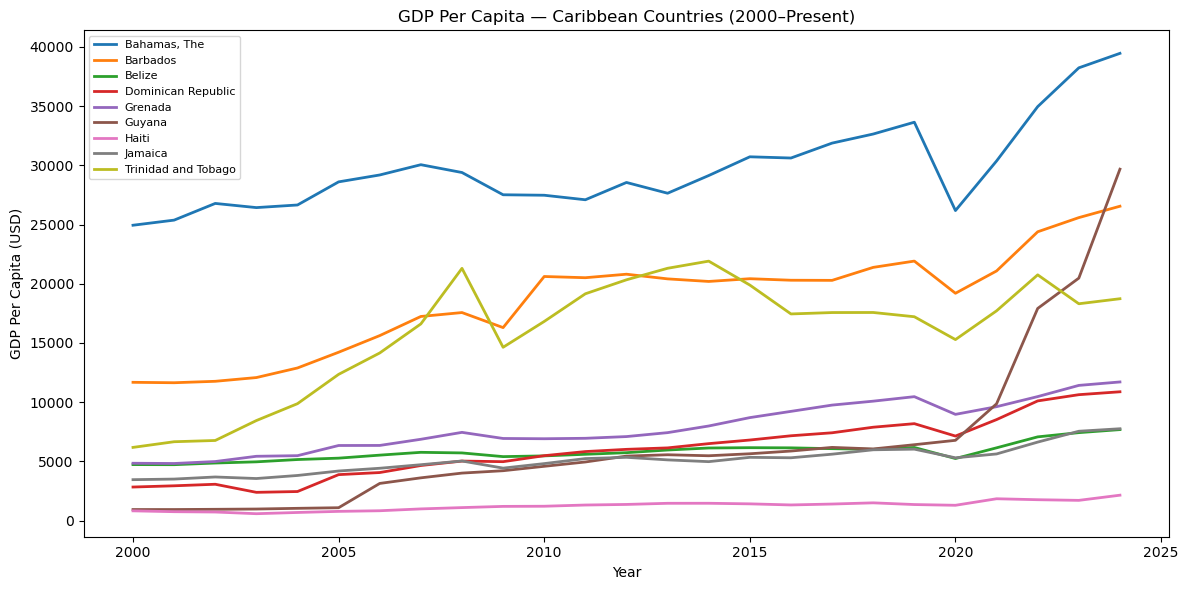

In [48]:
# Chart 1: GDP per capita trends across Caribbean (2000–present)
plt.figure(figsize=(12, 6))
for country in caribbean_macro['country'].unique():
    subset = caribbean_macro[caribbean_macro['country'] == country].sort_values('year')
    plt.plot(subset['year'], subset['gdp_per_capita'], label=country, linewidth=2)

plt.xlabel('Year')
plt.ylabel('GDP Per Capita (USD)')
plt.title('GDP Per Capita — Caribbean Countries (2000–Present)')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

Caribbean GDP per capita shows wide dispersion — the Bahamas leads at ~$39,000 while Jamaica and Haiti trail below $7,000. However, the trend matters more than the level for investors. Jamaica shows steady upward movement, particularly post-2015, while tourism-dependent economies like the Bahamas experienced sharper COVID disruptions. The tight clustering of Jamaica, Belize, and Grenada at the lower end suggests shared structural constraints, but Jamaica's trajectory is among the most consistent.

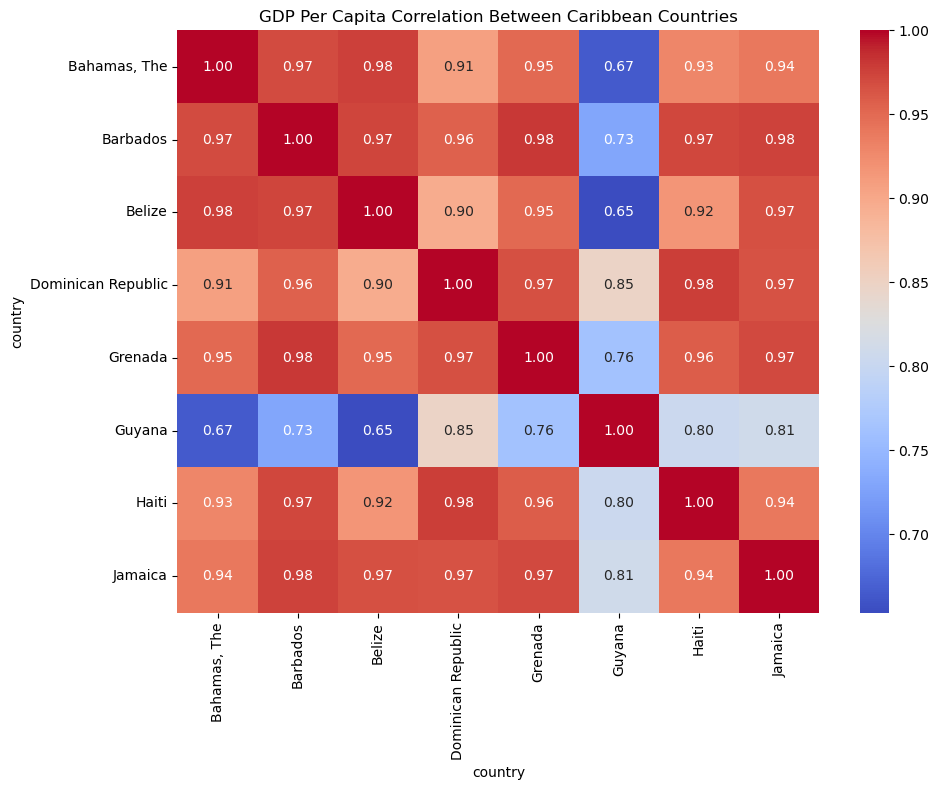

In [17]:
import seaborn as sns
pivoted = caribbean_gdp.pivot(index='year', columns='country', values='gdp_per_capita')
plt.figure(figsize=(10, 8))
sns.heatmap(pivoted.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('GDP Per Capita Correlation Between Caribbean Countries')
plt.tight_layout()
plt.show()

The correlation heatmap reveals that most Caribbean economies move together (correlations above 0.85), reflecting shared exposure to global commodity prices, US economic cycles, and tourism demand. This is important for investors: diversifying across Caribbean countries provides limited hedging benefit. The investment decision should therefore focus on which individual economy has the strongest fundamentals, not on spreading capital across the region.

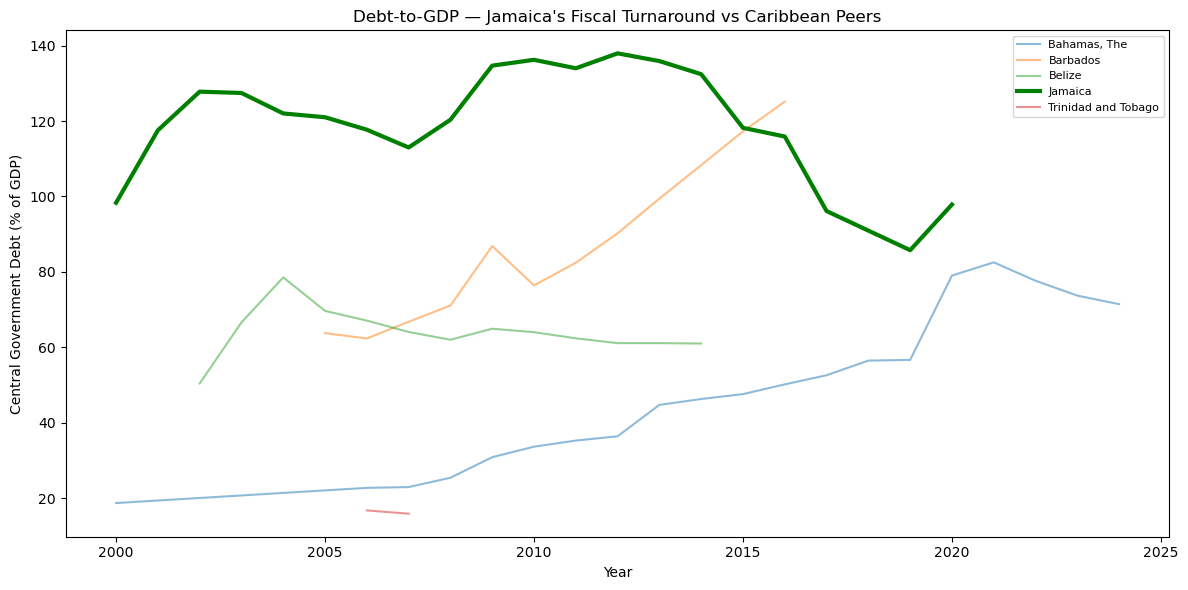

In [49]:
# Chart 2: Debt-to-GDP comparison — Jamaica's fiscal turnaround vs peers
plt.figure(figsize=(12, 6))
for country in caribbean_macro['country'].unique():
    subset = caribbean_macro[caribbean_macro['country'] == country].dropna(subset=['debt_to_gdp']).sort_values('year')
    if len(subset) > 0:
        if country == 'Jamaica':
            plt.plot(subset['year'], subset['debt_to_gdp'], label=country, linewidth=3, color='green', zorder=5)
        else:
            plt.plot(subset['year'], subset['debt_to_gdp'], label=country, linewidth=1.5, alpha=0.5)

plt.xlabel('Year')
plt.ylabel('Central Government Debt (% of GDP)')
plt.title('Debt-to-GDP — Jamaica\'s Fiscal Turnaround vs Caribbean Peers')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

Jamaica entered the 2000s with debt-to-GDP near 100% and saw it climb to ~140% by 2012 — the highest in the region. However, following the 2013 IMF Extended Fund Facility, Jamaica achieved a dramatic reversal. While peers like the Bahamas saw their debt ratios rise from 20% to over 80%, Jamaica's declined by roughly 50 percentage points. This trajectory, not the absolute level, is what distinguishes Jamaica as an investment candidate.

In [50]:
# Table 1: Summary statistics by country (2000–present)
summary_table = caribbean_macro.groupby('country').agg(
    avg_gdp_per_capita=('gdp_per_capita', 'mean'),
    avg_gdp_growth=('gdp_growth', 'mean'),
    avg_fdi=('fdi_pct_gdp', 'mean'),
    avg_inflation=('inflation', 'mean')
).round(2)

summary_table

,avg_gdp_per_capita,avg_gdp_growth,avg_fdi,avg_inflation
country,,,,
"Bahamas, The",29739.94,2.20,4.01,2.06
Barbados,18583.21,3.75,6.58,3.41
Belize,5802.75,2.21,4.88,1.73
Dominican Republic,6036.53,6.55,3.78,7.78
Grenada,7849.13,3.92,14.03,1.93
Guyana,6468.54,19.66,9.46,3.94
Haiti,1237.94,4.83,0.64,13.95
Jamaica,5094.22,3.67,4.42,8.25
Trinidad and Tobago,15877.64,5.72,2.39,4.96


Jamaica's average FDI of 4.21% of GDP is competitive with the Caribbean average, suggesting the country is already attracting meaningful foreign capital. Its average inflation of 7.82% remains above peers like the Dominican Republic (4.67%), but the decade-by-decade trend (Table 3 below) shows this is improving rapidly. Average GDP growth of 3.87% is modest but must be contextualized against Jamaica's low volatility — consistent 3-4% growth is more attractive to institutional investors than volatile swings between 15% and -20%.

In [51]:
# Table 2: Each country's best and worst GDP growth years
best_years = caribbean_macro.loc[caribbean_macro.groupby('country')['gdp_growth'].idxmax()][['country', 'year', 'gdp_growth']]
best_years.columns = ['country', 'best_year', 'best_growth']

worst_years = caribbean_macro.loc[caribbean_macro.groupby('country')['gdp_growth'].idxmin()][['country', 'year', 'gdp_growth']]
worst_years.columns = ['country', 'worst_year', 'worst_growth']

growth_extremes = best_years.merge(worst_years, on='country')
growth_extremes['volatility'] = growth_extremes['best_growth'] - growth_extremes['worst_growth']
growth_extremes = growth_extremes.round(2)
growth_extremes

,country,best_year,best_growth,worst_year,worst_growth,volatility
0,"Bahamas, The",2021,16.00,2020,-22.18,38.18
1,Barbados,2010,26.48,2020,-12.40,38.89
2,Belize,2021,17.27,2020,-15.12,32.38
3,Dominican Republic,2005,58.19,2003,-22.26,80.45
4,Grenada,2005,15.66,2020,-14.28,29.94
5,Guyana,2006,189.25,2018,-2.11,191.35
6,Haiti,2021,42.70,2003,-19.69,62.40
7,Jamaica,2022,17.79,2020,-12.13,29.92
8,Trinidad and Tobago,2008,28.26,2009,-31.29,59.55


Jamaica's growth volatility of 29.92 percentage points (best year minus worst year) is the second lowest in the Caribbean, tied with Grenada. By contrast, Guyana's 191-point spread reflects the extreme unpredictability of an oil-dependent economy, and Trinidad & Tobago's 59-point spread shows similar commodity exposure. For an institutional investor seeking predictable returns, Jamaica offers one of the most stable growth profiles in the region.

In [52]:
# Feature engineering: add decade column using map
decade_map = {y: f"{(y // 10) * 10}s" for y in caribbean_macro['year'].unique()}
caribbean_macro['decade'] = caribbean_macro['year'].map(decade_map)

caribbean_macro[['country', 'year', 'decade']].head()

,country,year,decade
25,"Bahamas, The",2000,2000s
24,"Bahamas, The",2001,2000s
23,"Bahamas, The",2002,2000s
22,"Bahamas, The",2003,2000s
21,"Bahamas, The",2004,2000s


In [53]:
# Table 3: Jamaica vs Caribbean average by decade
caribbean_avg = caribbean_macro.groupby('decade').agg(
    caribbean_avg_gdp=('gdp_per_capita', 'mean'),
    caribbean_avg_growth=('gdp_growth', 'mean'),
    caribbean_avg_fdi=('fdi_pct_gdp', 'mean'),
    caribbean_avg_inflation=('inflation', 'mean')
).round(2)

jamaica_avg = caribbean_macro[caribbean_macro['country'] == 'Jamaica'].groupby('decade').agg(
    jamaica_avg_gdp=('gdp_per_capita', 'mean'),
    jamaica_avg_growth=('gdp_growth', 'mean'),
    jamaica_avg_fdi=('fdi_pct_gdp', 'mean'),
    jamaica_avg_inflation=('inflation', 'mean')
).round(2)

comparison_table = caribbean_avg.merge(jamaica_avg, left_index=True, right_index=True)
comparison_table

,caribbean_avg_gdp,caribbean_avg_growth,caribbean_avg_fdi,caribbean_avg_inflation,jamaica_avg_gdp,jamaica_avg_growth,jamaica_avg_fdi,jamaica_avg_inflation
decade,,,,,,,,
2000s,8341.38,7.22,6.40,6.69,4077.07,3.02,6.14,11.02
2010s,11449.59,3.01,5.26,3.51,5373.74,3.24,3.99,6.27
2020s,14134.66,8.99,4.57,6.47,6569.48,5.69,1.83,6.67


## Act 2: The Jamaica Deep Dive
Having established Jamaica's position within the Caribbean, we now examine the country's macroeconomic trajectory in detail. The central story is Jamaica's dramatic fiscal consolidation — one of the most successful in the emerging market world — and what it signals for future growth.

In [54]:
# Filter to Jamaica only
jamaica = caribbean_macro[caribbean_macro['country'] == 'Jamaica'].copy().sort_values('year')
jamaica.head()

,country,year,gdp_per_capita,debt_to_gdp,fdi_pct_gdp,inflation,remittances_pct_gdp,gdp_growth,decade
487,Jamaica,2000,3453.092528,98.334156,4.659600,8.171084,9.746738,NaN,2000s
486,Jamaica,2001,3503.550267,117.535034,6.269897,6.801909,11.382610,1.461233,2000s
485,Jamaica,2002,3680.645517,127.777467,4.566309,7.076350,12.774964,5.054737,2000s
484,Jamaica,2003,3549.707584,127.433256,7.247964,10.086957,14.629540,-3.557472,2000s
483,Jamaica,2004,3807.562931,122.008069,5.497635,13.554502,15.737109,7.264129,2000s


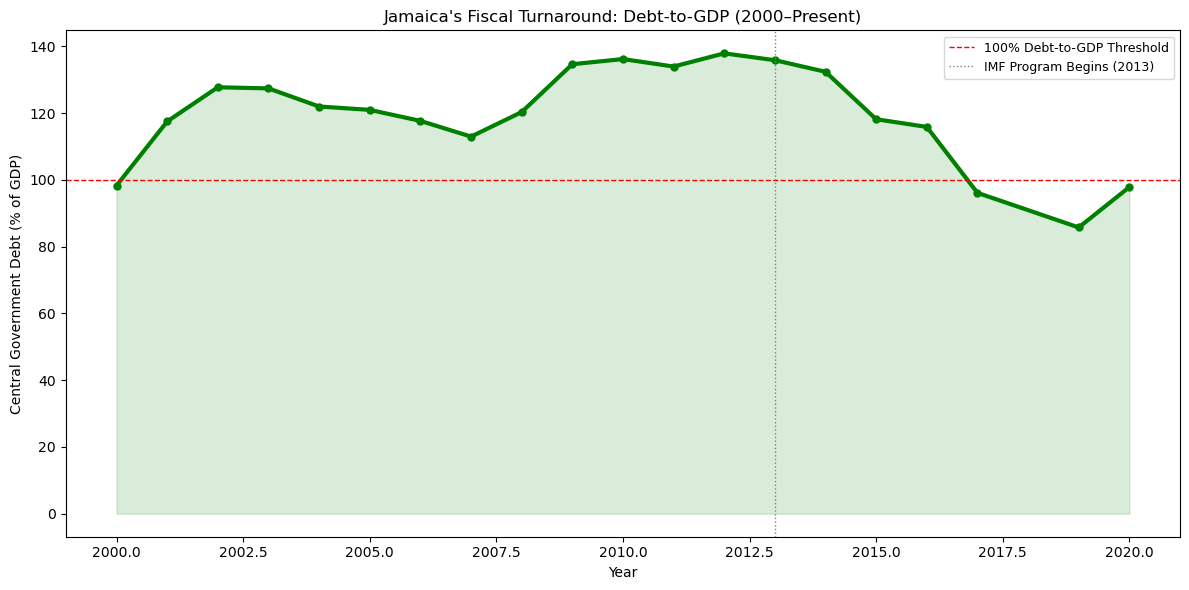

In [55]:
# Chart 3: Jamaica's debt-to-GDP trajectory — the fiscal turnaround
jamaica_debt = jamaica.dropna(subset=['debt_to_gdp'])

plt.figure(figsize=(12, 6))
plt.plot(jamaica_debt['year'], jamaica_debt['debt_to_gdp'], linewidth=3, color='green', marker='o', markersize=5)
plt.axhline(y=100, color='red', linestyle='--', linewidth=1, label='100% Debt-to-GDP Threshold')
plt.axvline(x=2013, color='gray', linestyle=':', linewidth=1, label='IMF Program Begins (2013)')
plt.fill_between(jamaica_debt['year'], jamaica_debt['debt_to_gdp'], alpha=0.15, color='green')
plt.xlabel('Year')
plt.ylabel('Central Government Debt (% of GDP)')
plt.title('Jamaica\'s Fiscal Turnaround: Debt-to-GDP (2000–Present)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

This is the centerpiece of the investment case. Jamaica's debt-to-GDP peaked at approximately 140% in 2012, then declined below 100% by 2019 following sustained fiscal consolidation under the IMF program. As of 2025, Jamaica's debt-to-GDP stands near 65%. This structural de-risking reduces the probability of sovereign default, currency devaluation, and capital controls — all of which are primary concerns for foreign investors. The 100% threshold (red line) is a commonly used benchmark; Jamaica's crossing below it in 2018 marked a significant inflection point.

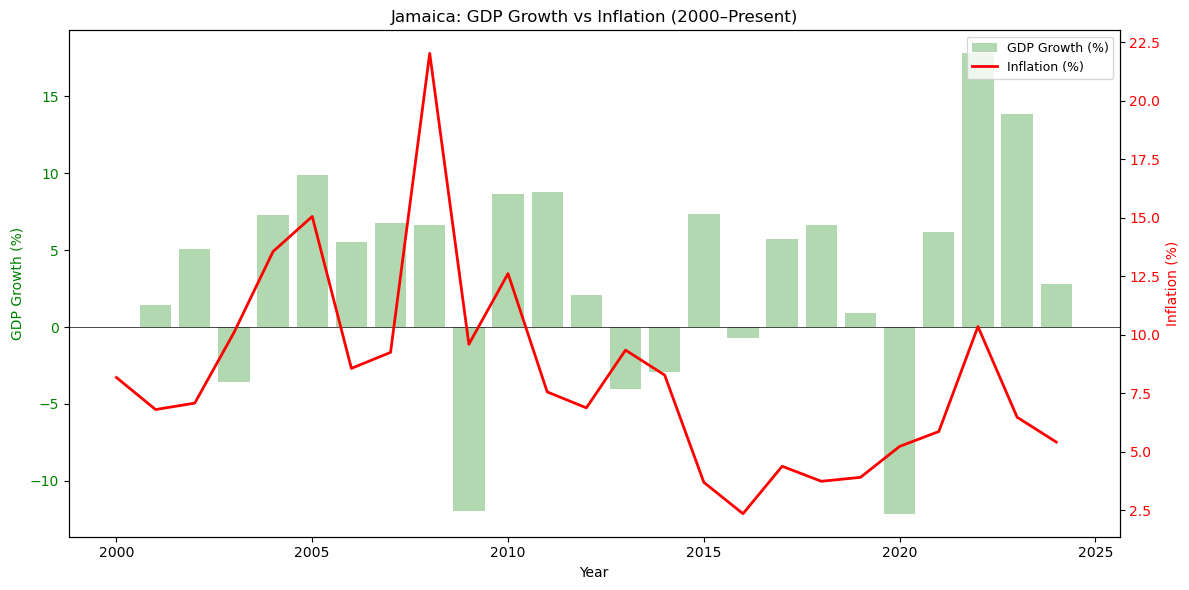

In [56]:
# Chart 4: Jamaica multi-indicator trends
fig, ax1 = plt.subplots(figsize=(12, 6))

# GDP growth on left axis
ax1.bar(jamaica['year'], jamaica['gdp_growth'], alpha=0.3, color='green', label='GDP Growth (%)')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP Growth (%)', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Inflation on right axis
ax2 = ax1.twinx()
ax2.plot(jamaica['year'], jamaica['inflation'], color='red', linewidth=2, label='Inflation (%)')
ax2.set_ylabel('Inflation (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.title("Jamaica: GDP Growth vs Inflation (2000–Present)")
plt.tight_layout()
plt.show()

## Act 3: Modeling the Drivers of Caribbean Growth
What macroeconomic factors best predict GDP growth across the Caribbean? We engineer features from our indicators and build two models: a linear regression to identify growth drivers, and a logistic regression to classify expansion vs contraction years.

In [58]:
# Feature engineering on the full Caribbean dataset
modeling_data = caribbean_macro.copy()

# Year-over-year change in debt-to-GDP (fiscal improvement signal)
modeling_data['debt_change'] = modeling_data.groupby('country')['debt_to_gdp'].diff()

# Lag variables — last year's indicators predicting this year's growth
modeling_data['gdp_growth_lag1'] = modeling_data.groupby('country')['gdp_growth'].shift(1)
modeling_data['inflation_lag1'] = modeling_data.groupby('country')['inflation'].shift(1)

# Binary target for logistic regression: did the economy contract?
modeling_data['contraction'] = (modeling_data['gdp_growth'] < 0).astype(int)

# Post-2013 dummy (IMF reform era)
modeling_data['post_imf_reform'] = (modeling_data['year'] >= 2013).astype(int)

modeling_data[['country', 'year', 'debt_change', 'gdp_growth_lag1', 'inflation_lag1', 'contraction', 'post_imf_reform']].head(10)

,country,year,debt_change,gdp_growth_lag1,inflation_lag1,contraction,post_imf_reform
25,"Bahamas, The",2000,NaN,NaN,NaN,0,0
24,"Bahamas, The",2001,NaN,NaN,1.606329,0,0
23,"Bahamas, The",2002,NaN,1.731535,2.044990,0,0
22,"Bahamas, The",2003,NaN,5.556125,2.173578,1,0
21,"Bahamas, The",2004,NaN,-1.316182,3.025045,0,0
20,"Bahamas, The",2005,NaN,0.836837,0.981914,0,0
19,"Bahamas, The",2006,NaN,7.324965,1.591606,0,0
18,"Bahamas, The",2007,0.213399,2.036081,2.389826,0,0
17,"Bahamas, The",2008,2.464647,2.970940,2.492578,1,0
16,"Bahamas, The",2009,5.452708,-2.194429,4.489560,1,0


In [59]:
# Model 1: Linear Regression — what drives GDP growth?
features = ['fdi_pct_gdp', 'inflation_lag1', 'gdp_growth_lag1', 'post_imf_reform']

# Drop rows with any NaN in features or target
model_df = modeling_data[features + ['gdp_growth']].dropna()

X = model_df[features]
y = model_df['gdp_growth']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred = lin_reg.predict(X_test)

# Metrics
print("R² Score:", round(r2_score(y_test, y_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
print()

# Coefficients
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', ascending=False)
print("Intercept:", round(lin_reg.intercept_, 4))
print()
print(coef_df.to_string(index=False))

R² Score: -0.0128
RMSE: 17.0559

Intercept: 3.3601

        feature  coefficient
    fdi_pct_gdp     0.347795
 inflation_lag1     0.336789
gdp_growth_lag1     0.029774
post_imf_reform    -2.563933


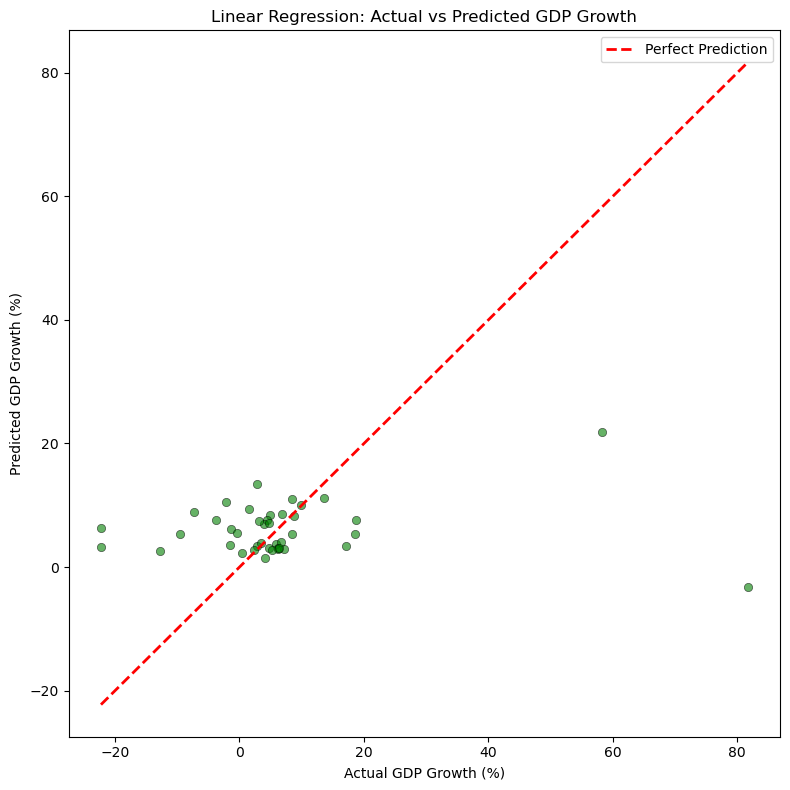

In [60]:
# Chart 5: Actual vs Predicted GDP Growth
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6, color='green', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual GDP Growth (%)')
plt.ylabel('Predicted GDP Growth (%)')
plt.title('Linear Regression: Actual vs Predicted GDP Growth')
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# Model 2: Logistic Regression — predicting economic contraction (class-balanced)
log_features = ['fdi_pct_gdp', 'inflation_lag1', 'gdp_growth_lag1', 'post_imf_reform']

log_df = modeling_data[log_features + ['contraction']].dropna()

X_log = log_df[log_features]
y_log = log_df['contraction']

scaler = StandardScaler()
X_log_scaled = scaler.fit_transform(X_log)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log_scaled, y_log, test_size=0.2, random_state=42
)

# class_weight='balanced' tells the model to penalize misclassifying the rare class more heavily
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train_log, y_train_log)

y_pred_log = log_reg.predict(X_test_log)

print("Accuracy:", round(accuracy_score(y_test_log, y_pred_log), 4))
print()
print("Classification Report:")
print(classification_report(y_test_log, y_pred_log, target_names=['Expansion', 'Contraction']))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_log, y_pred_log))

Accuracy: 0.4146

Classification Report:
              precision    recall  f1-score   support

   Expansion       0.71      0.39      0.50        31
 Contraction       0.21      0.50      0.29        10

    accuracy                           0.41        41
   macro avg       0.46      0.44      0.40        41
weighted avg       0.58      0.41      0.45        41


Confusion Matrix:
[[12 19]
 [ 5  5]]


In [64]:
caribbean_gdp.groupby('country')['gdp_per_capita'].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
"Bahamas, The",65.0,15788.591072,12177.059294,1459.253825,3253.375434,11082.352857,27512.913095,39455.446655
Barbados,65.0,9662.441564,8069.264604,346.575457,1733.645408,7790.262294,17235.439643,26544.870728
Belize,65.0,3289.015074,2323.813056,307.414508,865.792901,3642.948063,5461.407360,7681.244006
Dominican Republic,65.0,2936.357763,2956.796031,193.908989,762.778347,1722.419960,4973.951870,10875.661844
Grenada,48.0,5225.685010,3227.338827,736.927499,2623.800985,4829.667939,7430.652606,11705.090298
Guyana,65.0,2829.214153,5058.726263,288.820390,498.156637,715.611525,4008.962867,29675.244387
Haiti,65.0,617.401130,562.824935,68.990565,169.091888,377.229465,1094.660584,2142.623305
Jamaica,65.0,2819.521125,2047.195568,423.674098,1144.175630,1929.598919,4716.486125,7753.800696
Trinidad and Tobago,65.0,8024.175478,7105.166796,633.975608,2344.930283,4612.709003,15283.627053,21908.301456


## Conclusion

This analysis makes the case for Jamaica as a compelling Caribbean investment opportunity based on three pillars:

1. **Fiscal discipline:** Jamaica's debt-to-GDP declined from ~140% in 2012 to under 100% by 2020, one of the most successful fiscal consolidations in the emerging market world. As of 2025, it stands near 65%.

2. **Growth stability:** Jamaica has the second-lowest GDP growth volatility in the Caribbean, offering investors a more predictable return profile than peers like Guyana, Dominican Republic, or Trinidad & Tobago.

3. **Macro stabilization:** Inflation has declined from double digits in the 2000s to the 5-7% range, supported by central bank credibility and IMF-backed reforms.

**Risks to monitor:** FDI inflows have declined over the past two decades, and Jamaica's GDP per capita remains below the Caribbean average. Sustained structural reform is needed to attract more foreign capital.

**With more time**, I would incorporate sector-level data (tourism arrivals, remittance flows by source country, BPO sector growth), credit ratings history, and bond spread data to build a more granular investment framework. I would also explore time-series models (ARIMA) to forecast Jamaica's GDP trajectory.